We'll build our first Convolutional Neural Network (CNN) from scratch.

This notebook is adapted from [Dataflowr Module's 6 online ressource](https://dataflowr.github.io/website/modules/6-convolutional-neural-network/).

To access this notebook on colab: https://colab.research.google.com/drive/1iXf40kserEFYc-KX8V4QosOF6059xWbz?usp=sharing.

## 1. Preparations

In [1]:
%matplotlib inline
import math,sys,os,numpy as np
from numpy.linalg import norm
from matplotlib import pyplot as plt
import matplotlib as mpl

import torch
import torchvision
from torchvision import models,transforms,datasets
from torch.utils.data.sampler import SubsetRandomSampler

# Formatting the plots
plt.rcParams['figure.figsize'] = [6,6]
plt.rcParams['font.size'] = 18
plt.rcParams['font.weight'] = 'normal'
plt.style.use('default')
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['mathtext.rm'] = 'serif'
mpl.rcParams['font.size'] = 22
mpl.rcParams['axes.formatter.limits'] = (-6, 6)
mpl.rcParams['axes.formatter.use_mathtext'] = True
mpl.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
mpl.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
mpl.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True

Download MNIST data on disk and convert it to pytorch compatible formatting.

```torchvision.datasets``` features support (download, formatting) for a collection of popular datasets. The list of available datasets in ```torchvision``` can be found [here](http://pytorch.org/docs/master/torchvision/datasets.html).

Note that the download is performed only once. The function will always check first if the data is already on disk.


In [2]:
root_dir = './data/MNIST/'
torchvision.datasets.MNIST(root=root_dir,download=True)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data/MNIST/
    Split: Train

MNIST datasets consists of small images of hand-written digits. The images are grayscale and have size 28 x 28. There are 60,000 training images and 10,000 testing images.

In [3]:
train_set = datasets.MNIST(
    root=root_dir, train=True, download=True,
    transform=transforms.ToTensor()
)

Define and initialize a data loader for the MNIST data already downloaded on disk.

In [4]:
MNIST_dataset = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=True, num_workers=1)

For the current notebook, we can format data as _numpy ndarrays_ which are easier to plot in matplotlib. The same operations can be easily performed on _pytorch Tensors_.

In [5]:
images = train_set.data.numpy().astype(np.float32)/255
labels = train_set.targets.numpy()

> **Q1.** What class of problems are we focusing on? Enumerate some methods that we could use to solve it.

> **Q2.** How many data are there in the dataset? Is it balanced?

(60000, 28, 28) (60000,)


Text(0, 0.5, 'Number of samples')

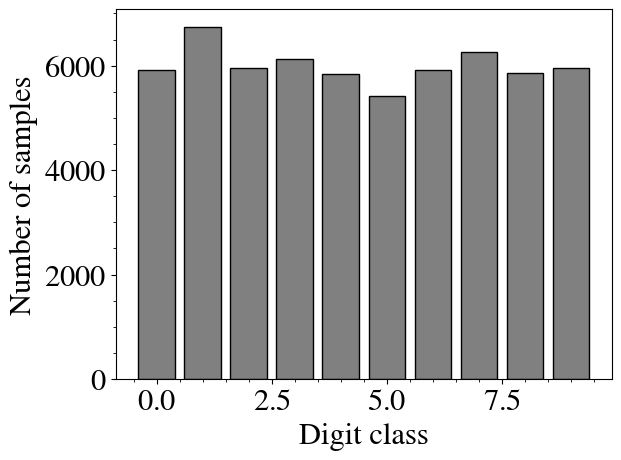

In [6]:
print(images.shape,labels.shape)

_, counts = np.unique(labels, return_counts=True)
plt.bar(_, counts, ec='k', fc='grey')
plt.xlabel('Digit class')
plt.ylabel('Number of samples')

## 2. Data visualization

For convenience we define a few functions for formatting and plotting our image data

In [7]:
# plot multiple images
def plots(ims, interp=False, titles=None):
    ims=np.array(ims)
    mn,mx=ims.min(),ims.max()
    f = plt.figure(figsize=(12,24))
    for i in range(len(ims)):
        sp=f.add_subplot(1, len(ims), i+1)
        if not titles is None: sp.set_title(titles[i], fontsize=18)
        plt.imshow(ims[i], interpolation=None if interp else 'none', vmin=mn,vmax=mx)
    # Remove ticks from all plots
    for ax in plt.gcf().axes:
        ax.set_xticks([])
        ax.set_yticks([])

# plot a single image
def plot(im, interp=False):
    f = plt.figure(figsize=(3,6), frameon=True)
    plt.imshow(im, interpolation=None if interp else 'none')

plt.gray()
plt.close()

Text(0.5, 1.0, 'Label: 7')

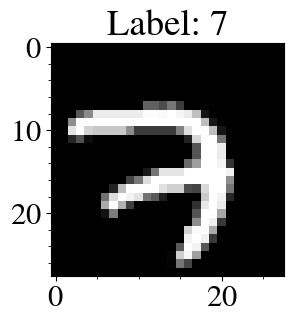

In [8]:
# Usage example for a single image
plot(images[5000])
plt.title(f'Label: {labels[5000]}')

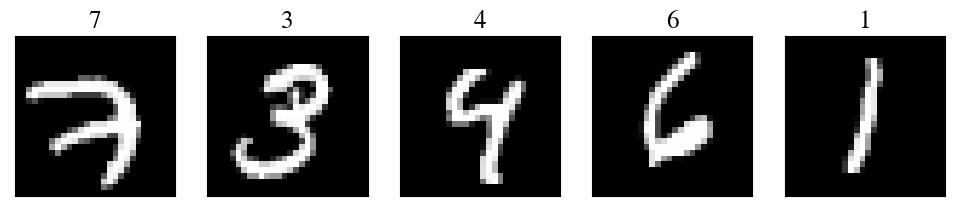

In [9]:
# Usage example for a multiple image
plots(images[5000:5005], titles=labels[5000:5005])

## 3. A simple classifier

In this section we will construct a **basic binary classifier** that will tell us whether a given image depicts a _one_ or an _eight_.

We first fetch all images from the _eight_ class and from the _one_ class.

In [10]:
n=len(images)

eights=[images[i] for i in range(n) if labels[i]==8]
ones=[images[i] for i in range(n) if labels[i]==1]

In [11]:
len(eights), len(ones)

(5851, 6742)

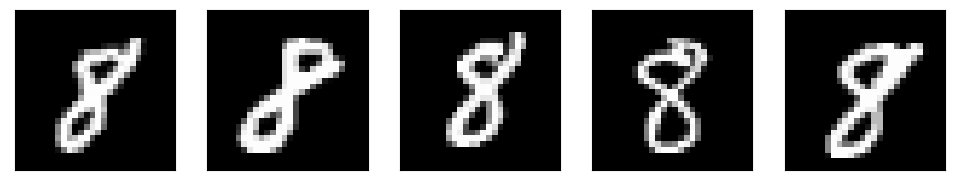

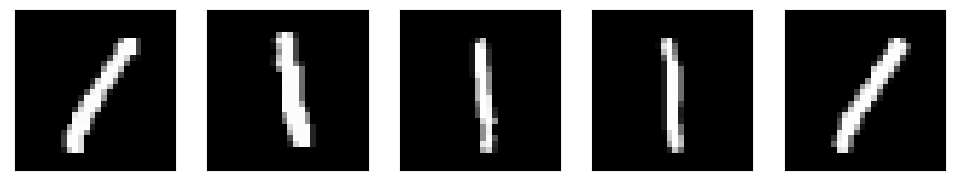

In [12]:
plots(eights[:5])
plots(ones[:5])

We keep the first 1000 digits of each class for the validation set and keep the rest for training.

In [13]:
test8 = np.array(eights[0:1000])
test1 = np.array(ones[0:1000])
train8 = np.array(eights[1000:])
train1 = np.array(ones[1000:])

> **Q3.** Our basic classifier will be the L2 distance between an image and the average of the training image in the class. Compute and visualise these representatives for class _one_ and _eight_.

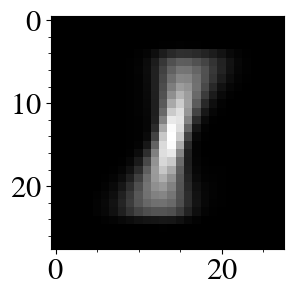

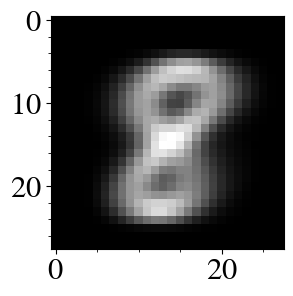

In [14]:
average8 =  np.mean(train8, axis=0)
average1 =  np.mean(train1, axis=0)

plot(average1)
plot(average8)

We built a 'typical representative' of the eights and a 'typical representative' of the ones. Now for a new sample from the test set, we compute the distance between this sample and our two representatives and classify the sample with the label of the closest representative.

The functions below compute the distance between 2 images.

In [15]:
# sum of squared distance
def sse(a,b):
    return ((a-b)**2).sum()

# return 1 if closest to 8 and 0 otherwise
def is8_raw_n2(im):
    return 1 if sse(im,average1) > sse(im,average8) else 0

The code below computes the several associations of predictions (wrong or false) for each class.

In [16]:
nb_8_predicted_8, nb_1_predicted_8 = [np.array([is8_raw_n2(im) for im in ims]).sum() for ims in [test8, test1]]

nb_8_predicted_1, nb_1_predicted_1 = [np.array([(1-is8_raw_n2(im)) for im in ims]).sum() for ims in [test8, test1]]

# Code to check that the sums are correct
print(nb_8_predicted_1+nb_8_predicted_8, nb_1_predicted_1+nb_1_predicted_8)

print(f'Number of eights predicted as eights: {nb_8_predicted_8}')
print(f'Number of ones predicted as eights: {nb_1_predicted_8}')

print(f'Number of eights predicted as ones: {nb_8_predicted_1}')
print(f'Number of ones predicted as ones: {nb_1_predicted_1}')

1000 1000
Number of eights predicted as eights: 912
Number of ones predicted as eights: 27
Number of eights predicted as ones: 88
Number of ones predicted as ones: 973


To quantify the quality of our classification, we use the precision and recall scores (source [wikipedia](https://en.wikipedia.org/wiki/Precision_and_recall))

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/1024px-Precisionrecall.svg.png" alt="Drawing" style="width: 500px;"/>

In [17]:
def compute_scores(nb_8_predicted_8,nb_8_predicted_1,nb_1_predicted_1,nb_1_predicted_8):
    Precision_8 = nb_8_predicted_8/(nb_8_predicted_8+nb_1_predicted_8)
    Recall_8 = nb_8_predicted_8/(nb_8_predicted_1+nb_8_predicted_8)
    Precision_1 = nb_1_predicted_1/(nb_1_predicted_1+nb_8_predicted_1)
    Recall_1 = nb_1_predicted_1/(nb_1_predicted_1+nb_1_predicted_8)
    return Precision_8, Recall_8, Precision_1, Recall_1

Precision_8, Recall_8, Precision_1, Recall_1 = compute_scores(nb_8_predicted_8,nb_8_predicted_1,nb_1_predicted_1,nb_1_predicted_8)

print('precision 8:', Precision_8, 'recall 8:', Recall_8)
print('precision 1:', Precision_1, 'recall 1:', Recall_1)
print('accuracy :', (Recall_1+Recall_8)/2)

precision 8: 0.9712460063897763 recall 8: 0.912
precision 1: 0.9170593779453345 recall 1: 0.973
accuracy : 0.9425


The score is already quite good with precisions and recall above 90%. You can try what happens it with other combination of classes by just changing the cell where we load `train1`, `train8`, `test1` and `test8`.

This is our baseline for our 1-8 binary classification task. Now your task will be to do better with convolutions!

## 4. Filters and convolutions

Let start with this visual explanation of [Interactive image kernels](http://setosa.io/ev/image-kernels/)

In some fields, convolution or filtering can be better understood as _correlations_. 
In practice we slide the filter matrix over the image (a bigger matrix) always selecting patches from the image with the same size as the filter. We compute the dot product between the filter and the image patch and store the scalar response which reflects the degree of similarity/correlation between the filter and image patch.

Here is a simple 3x3 filter, ie a 3x3 matrix (see [Sobel operator](https://en.wikipedia.org/wiki/Sobel_operator) for more examples)

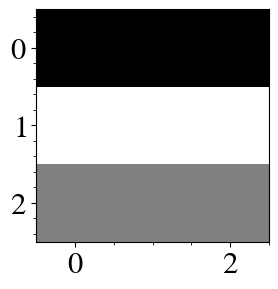

In [18]:
top=[[-1,-1,-1],
     [ 1, 1, 1],
     [ 0, 0, 0]]

plot(top)

We now create a toy image, to understand how convolutions operate.

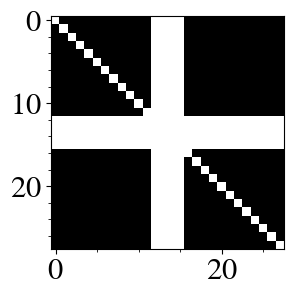

In [19]:
cross = np.zeros((28,28))
cross += np.eye(28)
for i in range(4):
    cross[12+i,:] = np.ones(28)
    cross[:,12+i] = np.ones(28)

plot(cross)

Our `top` filter should highlight top horizontal border in the image.

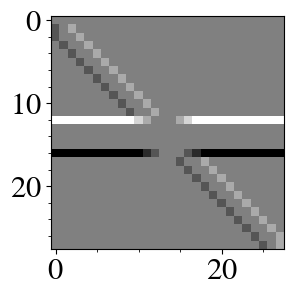

In [20]:
from scipy.ndimage import convolve, correlate

corr_cross = correlate(cross, top)

plot(corr_cross)

In [21]:
?correlate

Signature: correlate(input, weights, output=None, mode='reflect', cval=0.0, origin=0)
Docstring:
Multidimensional correlation.

The array is correlated with the given kernel.

Parameters
----------
input : array_like
    The input array.
weights : ndarray
    array of weights, same number of dimensions as input
output : array or dtype, optional
    The array in which to place the output, or the dtype of the
    returned array. By default an array of the same dtype as input
    will be created.
mode : {'reflect', 'constant', 'nearest', 'mirror', 'wrap'}, optional
    The `mode` parameter determines how the input array is extended
    beyond its boundaries. Default is 'reflect'. Behavior for each valid
    value is as follows:

    'reflect' (`d c b a | a b c d | d c b a`)
        The input is extended by reflecting about the edge of the last
        pixel. This mode is also sometimes referred to as half-sample
        symmetric.

    'constant' (`k k k k | a b c d | k k k k`)
        Th

Check the size of the output image. What happened to its border?

In [22]:
corr_cross.shape

(28, 28)

### Padding

![padding](https://dataflowr.github.io/notebooks/Module6/img/padding_conv.gif)

source: [Convolution animations](https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md)

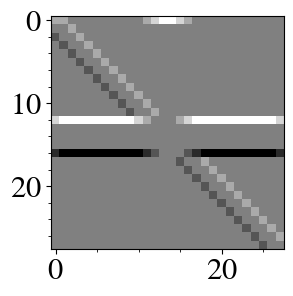

In [23]:
# To see the role of padding
corr_cross = correlate(cross, top, mode='constant')
plot(corr_cross)

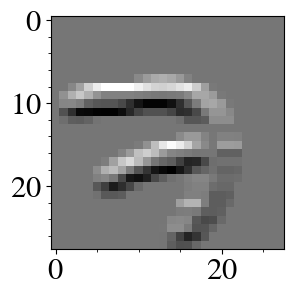

In [24]:
corrtop = correlate(images[5000], top)
plot(corrtop)

Let's generate a few more variants of our simple 3x3 filter

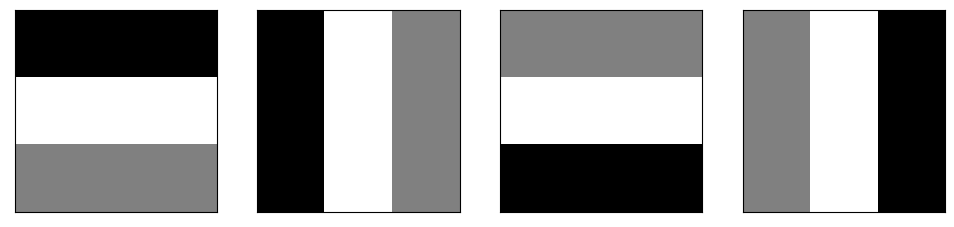

In [25]:
straights=[np.rot90(top,i) for i in range(4)]
plots(straights)

We proceed similarly to generate a set of filters with a different behavior

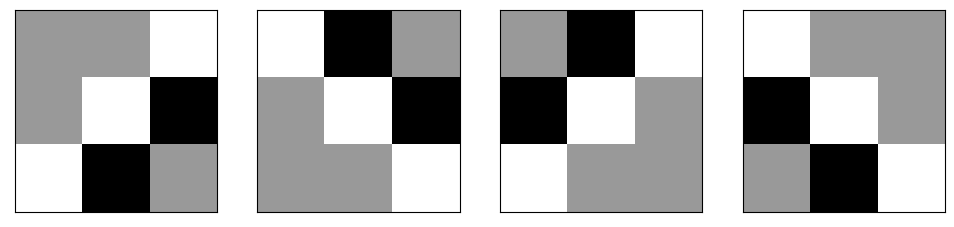

In [26]:
br=[[ 0, 0, 1],
    [ 0, 1,-1.5],
    [ 1,-1.5, 0]]

diags = [np.rot90(br,i) for i in range(4)]
plots(diags)

We can compose filters to obtain more complex patterns

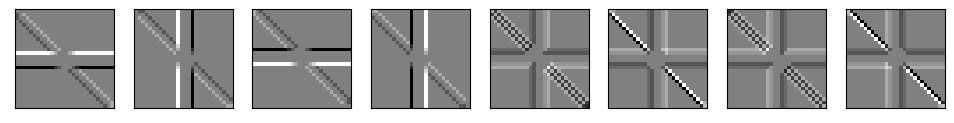

In [27]:
rots = straights + diags
corrs_cross = [correlate(cross, rot) for rot in rots]
plots(corrs_cross)

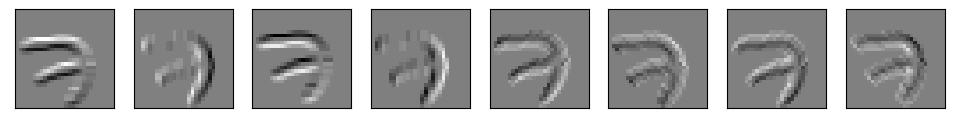

In [28]:
rots = straights + diags
corrs = [correlate(images[5000], rot) for rot in rots]
plots(corrs)

### Downsampling

Next we illustrate the effect of downsampling to reduce the spatial resolution of the maps. We select the most basic downsampling technique: __max pooling__. We keep only the maximum value for sliding windows of size ```7x7```.
__Max pooling__ is a handy technique with a few useful perks:
- Since it selects the maximum values it ensures invariance to translations
- Reducing the size is helpful since data becomes more compact and easier to compare
- We will see later in this course that since max pooling reduces the size of our images, the operations performed later on in the network have bigger receptive field / concern a bigger patch in the input image and allow the discovery of higher level patterns.

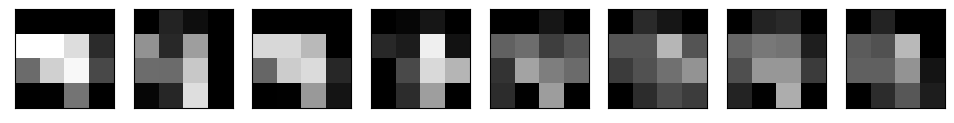

In [29]:
import skimage
from skimage.measure import block_reduce

def pool(im):
    return block_reduce(im, (7,7), np.max)

plots([pool(im) for im in corrs])

### Classifier with convolutions and downsampling

To this end we select a set of training images depicting _eights_ and _ones_, we convolve them with our set of filters, pool them and average them for each class and filter. We will thus obtain a set of _representative_ signatures for _eights_ and for _ones_ with these filters. 
Given a new test image we compute its features by convolution and pooling with the same filters and then compare them with the _representative_ features. The class with the most _similar_ features is chosen as prediction.


Below we convolve the `train8` with our bank of filters, perform max pooling on the responses and store them in ```pool8```.

In [30]:
pool8 = [np.array([pool(correlate(im, rot)) for im in train8]) for rot in rots]

In [31]:
len(pool8), pool8[0].shape

(8, (4851, 4, 4))

We plot the result of the first filter+pooling on the first 5 _eights_ in our set. 

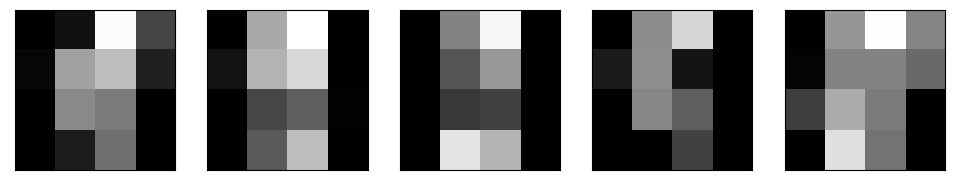

In [32]:
plots(pool8[0][0:5])

For the 4 first _eights_ in our set, we plot the result of the 8 filters+pooling

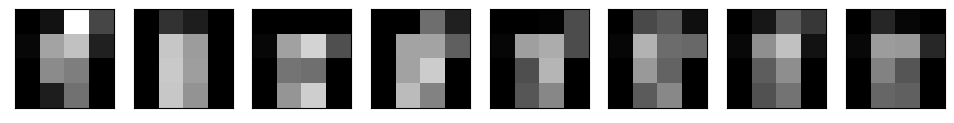

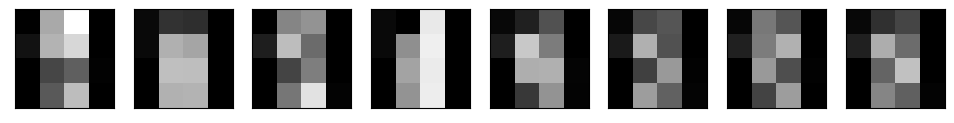

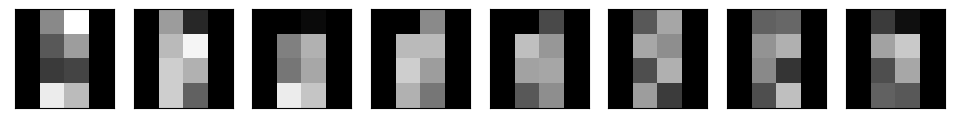

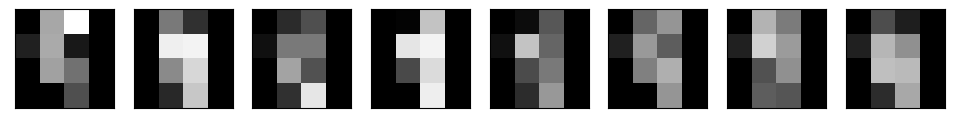

In [33]:
plots([pool8[i][0] for i in range(8)])
plots([pool8[i][1] for i in range(8)])
plots([pool8[i][2] for i in range(8)])
plots([pool8[i][3] for i in range(8)])

We normalize the data in order to smoothen activations and bring them to similar ranges of values

In [34]:
def normalize(arr):
    return (arr-arr.mean())/arr.std()

Next we compute the average _eight_ by averaging all responses for each filter from _rots_.

In [35]:
filts8 = np.array([ims.mean(axis=0) for ims in pool8])
filts8 = normalize(filts8)

We should obtain a set of canonical _eights_ responses for each filter.

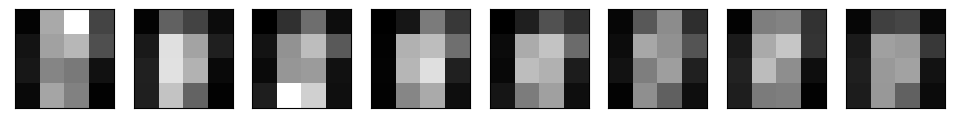

In [36]:
plots(filts8)

We proceed similarly with training samples from the _one_ class and plot the canonical _ones_.

In [37]:
pool1 = [np.array([pool(correlate(im, rot)) for im in train1]) for rot in rots]
filts1 = np.array([ims.mean(axis=0) for ims in pool1])
filts1 = normalize(filts1)

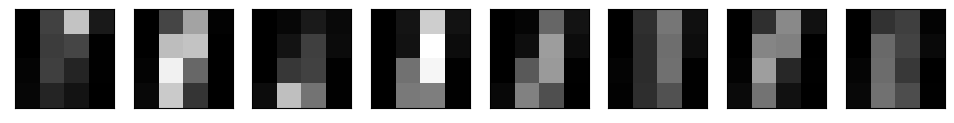

In [38]:
plots(filts1)

> **Q4.** Do you notice any differences between ```filts8``` and ```filts1```? Which ones?

We define a function that correlates a given image with all filters from ```rots``` and max pools the responses.

In [39]:
def pool_corr(im):
    return np.array([pool(correlate(im, rot)) for rot in rots])

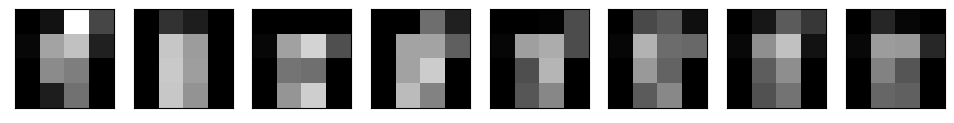

In [40]:
plots(pool_corr(eights[1000]))

True

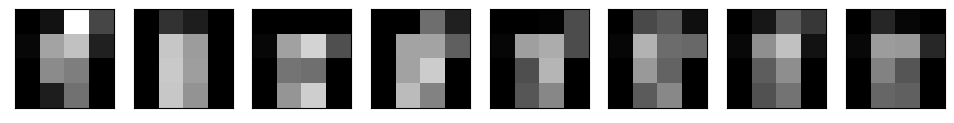

In [41]:
#check 
plots([pool8[i][0] for i in range(8)])
np.allclose(pool_corr(eights[1000]),[pool8[i][0] for i in range(8)])

In [42]:
# function used for a voting based classifier that will indicate which one of the 
# two classes is most likely given the sse distances
# n2 comes from norm2
# is8_n2 returns 1 if it thinks it's an eight and 0 otherwise
def is8_n2(im):
    return 1 if sse(pool_corr(im),filts1) > sse(pool_corr(im),filts8) else 0

We perform a check to see if our function actually works. We correlate the an image of _eight_ with ```filts8``` and ```filts1```. It should give smaller distance for the _eights_.

In [43]:
sse(pool_corr(eights[0]), filts8), sse(pool_corr(eights[0]), filts1)

(103.67323, 126.09805)

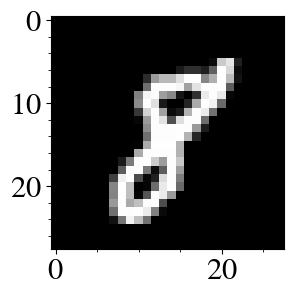

In [44]:
plot(eights[0])

We now test our classifier on the 1000 images of _eights_ and 1000 images of _ones_

In [45]:
nb_8_predicted_8, nb_1_predicted_8 = [np.array([is8_n2(im) for im in ims]).sum() for ims in [eights[:1000],ones[:1000]]]

nb_8_predicted_1, nb_1_predicted_1 = [np.array([(1-is8_n2(im)) for im in ims]).sum() for ims in [eights[:1000],ones[:1000]]]

In [46]:
Precisionf_8, Recallf_8, Precisionf_1, Recallf_1 = compute_scores(nb_8_predicted_8,nb_8_predicted_1,nb_1_predicted_1,nb_1_predicted_8)

print('precision 8:', Precisionf_8, 'recall 8:', Recallf_8)
print('precision 1:', Precisionf_1, 'recall 1:', Recallf_1)

print('')
print('Accuracy with convolutions:', (Recallf_1+Recallf_8)/2)
print('Accuracy of the baseline:', (Recall_1+Recall_8)/2)

precision 8: 0.963220675944334 recall 8: 0.969
precision 1: 0.9688128772635815 recall 1: 0.963

Accuracy with convolutions: 0.966
Accuracy of the baseline: 0.9425


We improved the accuracy while reducing the embedding size from a $28\times 28 = 784$ vector to a $4\times 4\times 8 = 128$ vector.

We have successfully built a classifier for _eights_ and _ones_ using features extracted with a bank of pre-defined features and a set of training samples. You will now build a neural net that will learn the weights of the filters.

## 5. Practicals: improving classification with Convolutional Neural Net

The first layer of your network will be a **convolutional layer** with $8$ filters of size $3\times 3$. Then you will apply a **max pooling** layer to reduce the size of the image to $4\times 4$ as we did above. This will produce, once flattened, a vector of size $4\times 4\times 8 = 128$. From this vector, you need to predict if the corresponding input is a $1$ or a $8$. So you are back to a classification problem as seen in previous lessons, so we will simply have a **fully-connected layer** followed by a **softmax** activation.

The first step when building a neural network model in PyTorch is to setup the data into an iterable object, called a [DataLoader](https://pytorch.org/docs/stable/data.html). It also allows to shuffle the data based on a given batch size.

> **Q5.** Remind: what are the use of train/validation/test sets; what is a batch size and what is it used for in optimization.

The code below create two dataloaders, one for training, one for validation.

In [47]:
BATCH_SIZE = 64         # Size of the batches
SIZE_IN = (1, 28, 28)   # Size of one input image
SIZE_OUT = 2           # Number of classes

# Split the dataset 
l8 = np.array(0)        # Label for digit 8
eights_dataset = [[torch.from_numpy(e.astype(np.float32)).unsqueeze(0), torch.from_numpy(l8.astype(np.int64))] for e in eights] # Get digit 8 images
l1 = np.array(1)        # Label for digit 1
ones_dataset = [[torch.from_numpy(e.astype(np.float32)).unsqueeze(0), torch.from_numpy(l1.astype(np.int64))] for e in ones]     # Get digit 1 images
train_dataset = eights_dataset[1000:] + ones_dataset[1000:]
test_dataset = eights_dataset[:1000] + ones_dataset[:1000]

train_loader = torch.utils.data.DataLoader(train_dataset,
    batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,
    batch_size=BATCH_SIZE, shuffle=True)

> **Q6.** Fill the code below to construct your CNN. You can have a lok at the [PyTorch.nn](https://pytorch.org/docs/stable/nn.html) documentation. Create an instance of your classifier.

In [48]:
import torch.nn as nn
import torch.nn.functional as F

class classifier(nn.Module):
    
    def __init__(self):
        super(classifier, self).__init__()
        # Specify your layers here (check the documentation)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.fc = nn.Linear(in_features=128, out_features=2)
        
    def forward(self,x):
        # implement your network here, use F.max_pool2d, F.log_softmax and do not forget to flatten your vector
        x = self.conv1(x)
        x = F.max_pool2d(x,7)
        x = self.fc(torch.flatten(x,start_dim=1))
        return F.log_softmax(x, dim=1)
    
conv_class = classifier()
print(conv_class)

classifier(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


Here we check that your model works on a batch.

In [49]:
X, y = next(iter(train_loader))      # Get a batch of data X and y
print(X.shape, y.shape)
y_conv = conv_class(X)

print(y_conv[0:10])
print(y[0:10])

torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([[-0.6047, -0.7902],
        [-0.6569, -0.7308],
        [-0.6133, -0.7799],
        [-0.6595, -0.7279],
        [-0.6454, -0.7433],
        [-0.6271, -0.7639],
        [-0.6690, -0.7179],
        [-0.5536, -0.8554],
        [-0.7012, -0.6851],
        [-0.6850, -0.7013]], grad_fn=<SliceBackward0>)
tensor([1, 0, 0, 1, 1, 1, 0, 0, 1, 1])


> **Q7.** Explain what is the output of the network. What should we do to obtain a classification?

In [50]:
print(y_conv.argmax(1))

tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])


> **Q8.** How many parameters does this network have? You may want to use the `.parameters()` attribute of the model giving back an iterator over the several layers.

In [51]:
n_param_tot = 0
for parameter in conv_class.parameters():
  n_param_tot += np.prod(parameter.shape)

print(n_param_tot)

# 8 kernels of size 3x3 + 8 biases in conv layer
# 128 inputs and 2 outputs + 2 biases in fc layer
print(8*3*3 + 8 + 128*2+2)

338
338


To train our neural network with the data at hand, we use the backpropagation algorithm and the stochastic gradient descent method.

> **Q9.** Remind how stochastic gradient descent works. We now need to specify a loss function and an optimization procedure. What is a loss that we can use in this case? You may want to check the documentation. Use the [SGD optimizer](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) and set the learning rate to $10^{-3}$.

In [78]:
conv_class = classifier()                   # Instantiate the model
loss_fn = torch.nn.CrossEntropyLoss()       # Cross entropy loss function
learning_rate = 1e-3                        # Learning rate
optimizer_cl = torch.optim.Adam(conv_class.parameters(), lr=learning_rate)        # SGD optimizer

> **Q10.** Complete the `train` function below.
To compute and update the gradient in Torch, there are four steps:
> * First compute the loss on the batch,
> * Clean your optimizer using the [`optimizer.zero_grad()`](https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html) function,
> * Call the [`backward()`](https://pytorch.org/docs/stable/generated/torch.Tensor.backward.html) function of the loss to compute the gradient,
> * Make a step in the opposite gradient direction using the [`optimizer.step()`](https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.step.html) function.

Make sure to save the train and validation loss functions to vizualize it afterwards.

In [79]:
from tqdm import tqdm

def train(model,data_loader,loss_fn,optimizer,n_epochs=1):
    model.train(True)
    loss_train = np.zeros(n_epochs)
    acc_train = np.zeros(n_epochs)
    pbar = tqdm(range(n_epochs))
    for epoch_num in pbar:
        running_corrects = 0.0
        running_loss = 0.0
        size = 0
        
        for data in data_loader:
            inputs, labels = data
            bs = labels.size(0)
            # --------------
            # YOUR CODE HERE
            # --------------
            outputs = model(inputs)             # Forward pass
            loss = loss_fn(outputs,labels)      # Compute loss
            optimizer.zero_grad()               # Zero gradients
            loss.backward()                     # Compute the gradient (backpropagation)
            optimizer.step()                    # Update weights
            _, preds = torch.max(outputs,1)     # Get predictions
            
            running_corrects += torch.sum(preds == labels)      # You need to compute the prediction 'preds'
            running_loss += loss.data
            size += bs
            
        epoch_loss = running_loss.item() / size
        epoch_acc = running_corrects.item() / size
        loss_train[epoch_num] = epoch_loss
        acc_train[epoch_num] = epoch_acc
        pbar.set_description(f'Epoch {epoch_num+1}/{n_epochs} - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        # print('Train - Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))
    return loss_train, acc_train

> **Q11.** Below we train your model for 20 epochs and plot the train loss. Comment the evolution of the train loss (or accuracy).

Epoch 100/100 - Loss: 0.0000 Acc: 0.9995: 100%|██████████| 100/100 [00:42<00:00,  2.34it/s]


Text(0.5, 1.0, 'Training accuracy vs Epochs')

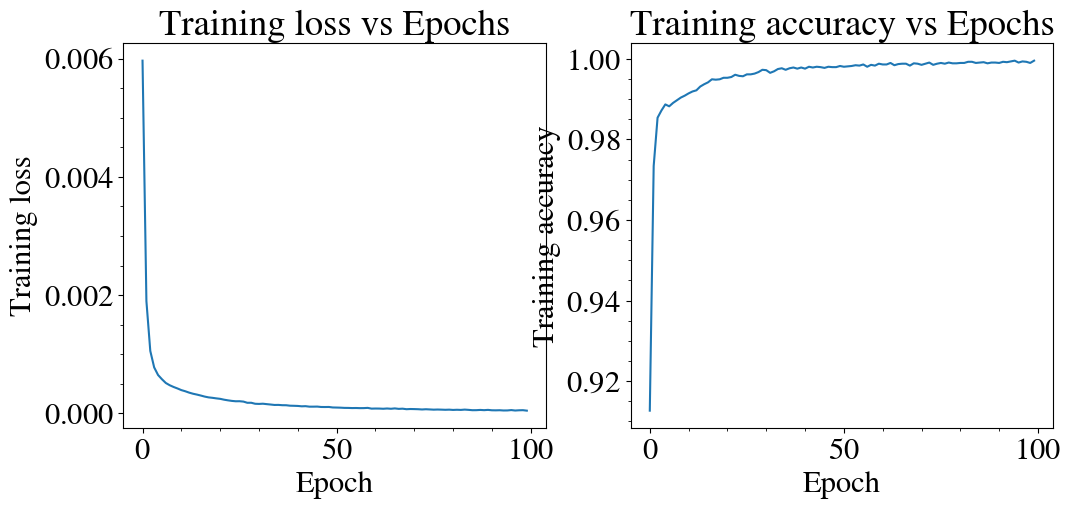

In [80]:
l_t, a_t = train(conv_class,
                 train_loader,
                 loss_fn,
                 optimizer_cl,
                 n_epochs=20)


# Plot both training loss and accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(l_t)
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('Training loss vs Epochs')
plt.subplot(1,2,2)
plt.plot(a_t)
plt.xlabel('Epoch')
plt.ylabel('Training accuracy')
plt.title('Training accuracy vs Epochs')

Our network seems to learn but we now need to check its accuracy on the test set.

In [81]:
def test(model,data_loader):
    model.train(False)

    running_corrects = 0.0
    running_loss = 0.0
    size = 0

    for data in data_loader:
        inputs, labels = data
            
        bs = labels.size(0)
        # --------------
        # YOUR CODE HERE to compute loss and accuracy
        # --------------
        outputs = model(inputs)
        loss = loss_fn(outputs,labels)
        _,preds = torch.max(outputs,1)
        running_corrects += torch.sum(preds == labels)
        running_loss += loss.data
        
        size += bs

    print('Test - Loss: {:.4f} Acc: {:.4f}'.format(running_loss / size, running_corrects.item() / size))

In [82]:
test(conv_class,test_loader)

Test - Loss: 0.0002 Acc: 0.9965


> **Q12.** Vanilla SGD is one way to optimize the network but there are more efficient ways. Try [`Adam`](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html) instead. Comment.

> **Q13.** Comment on the performance of your CNN. Compare it to the previous approaches (baseline and with convolutions from handcrafter kernels).

The CNN performs significantly better than the previous approaches. The baseline method achieved an accuracy of around 94% while the handcrafted kernels gave us 96%. The CNN reaches an accuracy of about 99.6% on the test set with Adam.

This improvement can be attributed to the CNN's ability to learn complex features through convolutional layers and pooling, which capture spatial hierarchies in the data. The previous method using handcrafted convolutions and pooling provided a good starting point, but the learned filters in the CNN are more effective at distinguishing between the digit classes. Overall, the CNN demonstrates the power of deep learning techniques: learning relevant features directly from the data that are well-suited for the task at hand.